# BT4012 - Fraudulent Cryptocurrency Transactions

**Kernel:** select `Python (bt4012)` (top-right) so this runs in `.venv`.

Data is pulled from the Kaggle API into the local kagglehub cache
(`~/.cache/kagglehub`) - nothing is stored in this repo.

In [1]:
# Python 3.9 here links against LibreSSL, which urllib3 v2 warns about on every
# HTTPS call. Must be filtered by message BEFORE urllib3 is first imported.
import warnings

warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL")

# Kaggle credentials live in .env (gitignored) as KAGGLE_USERNAME / KAGGLE_KEY.
from pathlib import Path

from dotenv import load_dotenv

ENV_PATH = Path.cwd() / ".env"
if not load_dotenv(ENV_PATH):
    warnings.warn(f"no .env loaded from {ENV_PATH}", stacklevel=2)


## 1. Credentials

`.env` (gitignored) holds the API token from <https://www.kaggle.com/settings>:

```
KAGGLE_KEY=KGAT_...
```

**Keep the `KGAT_` prefix.** The API accepts this token only as
`Authorization: Bearer <token>`; stripping the prefix gives HTTP 401.

The `kaggle` and `kagglehub` packages cannot use it - they only do HTTP Basic
with a username plus the 32-char `key` from a legacy `kaggle.json`, and neither
supports Bearer tokens outside a Kaggle notebook. `kaggle_data.py` in this repo
calls the REST API directly instead. `KAGGLE_USERNAME` is not needed.


In [2]:
import os

from kaggle_data import download_competition, list_files

token = os.getenv("KAGGLE_KEY")
if not token:
    raise RuntimeError("KAGGLE_KEY missing - check .env, then restart the kernel.")
print("token loaded, Bearer-style:", token.startswith("KGAT_"))


token loaded, Bearer-style: True


## 2. Download the competition data

Extracted to `~/.cache/bt4012/<competition>` - outside the repo, so nothing large
is ever staged for git. Cached: re-running is a no-op; pass `force=True` to refresh.


In [3]:
COMPETITION = "bt-4012-competition-2026"

for f in list_files(COMPETITION):
    print(f"{f['name']:28s} {f['totalBytes'] / 1e6:9.1f} MB")

DATA_DIR = download_competition(COMPETITION)
print("\ndata dir:", DATA_DIR)



sample_submission.csv              0.1 MB
test.csv                          49.6 MB
train.csv                        461.0 MB
txs_edgelist.csv                   4.5 MB

data dir: /Users/cheepheng/.cache/bt4012/bt-4012-competition-2026


## 3. Load

In [4]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
edges = pd.read_csv(DATA_DIR / "txs_edgelist.csv")

for name, df in [("train", train), ("test", test),
                 ("sample_submission", sample_submission), ("edges", edges)]:
    print(f"{name:20s} {df.shape}")

train                (141772, 168)
test                 (15329, 168)
sample_submission    (15329, 2)
edges                (234355, 2)


In [5]:
train.head()

,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49,feat_50,feat_51,feat_52,feat_53,feat_54,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69,feat_70,feat_71,feat_72,feat_73,feat_74,feat_75,feat_76,feat_77,feat_78,feat_79,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95,feat_96,feat_97,feat_98,feat_99,feat_100,feat_101,feat_102,feat_103,feat_104,feat_105,feat_106,feat_107,feat_108,feat_109,feat_110,feat_111,feat_112,feat_113,feat_114,feat_115,feat_116,feat_117,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127,feat_128,feat_129,feat_130,feat_131,feat_132,feat_133,feat_134,feat_135,feat_136,feat_137,feat_138,feat_139,feat_140,feat_141,feat_142,feat_143,feat_144,feat_145,feat_146,feat_147,feat_148,feat_149,feat_150,feat_151,feat_152,feat_153,feat_154,feat_155,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0

## 3b. Inspecting the data

141,772 x 168 is ~24M cells - too much to render at once. Three practical ways in:

1. **Un-truncate pandas** (next cell) so all 168 columns print instead of `...`.
2. **Data Wrangler** - right-click `train.csv` -> *Open in Data Wrangler*, or click
   a DataFrame in the Jupyter **Variables** panel. Gives a scrollable grid over all
   rows plus per-column histograms. Install the `ms-toolsai.datawrangler` extension.
3. **Summarise instead of scroll** - the column inventory below is usually what you
   actually want from "view everything".

In [6]:
# Show everything pandas would otherwise truncate.
pd.set_option("display.max_columns", None)   # all 168 columns
pd.set_option("display.width", None)         # don't wrap
pd.set_option("display.max_colwidth", None)

# Leave max_rows alone - printing 141,772 rows will hang the notebook.
# Use train.head(50), train.sample(50), or Data Wrangler for row-level browsing.
pd.set_option("display.max_rows", 100)

train.head()

,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49,feat_50,feat_51,feat_52,feat_53,feat_54,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69,feat_70,feat_71,feat_72,feat_73,feat_74,feat_75,feat_76,feat_77,feat_78,feat_79,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95,feat_96,feat_97,feat_98,feat_99,feat_100,feat_101,feat_102,feat_103,feat_104,feat_105,feat_106,feat_107,feat_108,feat_109,feat_110,feat_111,feat_112,feat_113,feat_114,feat_115,feat_116,feat_117,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127,feat_128,feat_129,feat_130,feat_131,feat_132,feat_133,feat_134,feat_135,feat_136,feat_137,feat_138,feat_139,feat_140,feat_141,feat_142,feat_143,feat_144,feat_145,feat_146,feat_147,feat_148,feat_149,feat_150,feat_151,feat_152,feat_153,feat_154,feat_155,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0

In [7]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [8]:
test.head()

,index,txId,time_step,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49,feat_50,feat_51,feat_52,feat_53,feat_54,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69,feat_70,feat_71,feat_72,feat_73,feat_74,feat_75,feat_76,feat_77,feat_78,feat_79,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95,feat_96,feat_97,feat_98,feat_99,feat_100,feat_101,feat_102,feat_103,feat_104,feat_105,feat_106,feat_107,feat_108,feat_109,feat_110,feat_111,feat_112,feat_113,feat_114,feat_115,feat_116,feat_117,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127,feat_128,feat_129,feat_130,feat_131,feat_132,feat_133,feat_134,feat_135,feat_136,feat_137,feat_138,feat_139,feat_140,feat_141,feat_142,feat_143,feat_144,feat_145,feat_146,feat_147,feat_148,feat_149,feat_150,feat_151,feat_152,feat_153,feat_154,feat_155,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,feat_165
0,0,200459281,36,-0.172879,-0.058452,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.163536,-0.169352,-0.049707,-0.165839,-0.028741,-0.035391,-0.042955,-0.013282,-0.057065,-0.171067,-0.172840,-0.176141,0.887058,0.884557,-0.132105,-0.144045,-0.080147,-0.149199,-0.010763,-0.012107,-0.132105,-0.144040,-0.080147,-0.149198,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.211084,-0.224180,-0.075256,-0.219162,0.037468,0.043444,-0.211222,-0.227604,-0.097895,-0.220010,0.036577,0.042345,1.041317,0.722046,-0.232553,0.928888,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163115,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.01764,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293853,-0.761944,-0.694210,-0.720952,1.135523,1.135279,-0.170634,-0.202741,-0.116817,-0.192915,-0.014659,-0.018849,0.801938,0.803958,-0.083459,0.805795,-0.088798,-0.090437,-0.088200,-0.156977,-0.134546,-0.119971,-0.003175,-0.004094,1.023860,0.787435,-0.349933,0.939106,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.124290,-0.193567,-0.180149,-0.207226,1.064205,1.063787,0.739947,0.502358,-0.301617,0.663148,1.342003,1.340733,0.398289,4.421702,5.327376,4.467085,1.301966,1.301281,0.117111,0.669709,0.759748,0.445895,1.488113,1.487932,0.090912,1.794379,2.262621,1.947206,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
1,1,199944769,36,-0.172828,0.339970,1.018602,0.178180,-0.043875,0.222447,-0.061584,-0.163620,-0.169419,-0.049636,-0.165915,-0.684027,-0.280462,-0.042955,-0.013282,-0.057112,-0.171012,-0.172773,-0.176081,0.887058,0.884557,-0.139732,-0.148899,-0.080135,-0.155656,-1.256340,-1.350850,-0.139734,-0.148895,-0.080135,-0.155656,-1.256230,-1.350662,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.229204,-0.054534,-0.232386,-2.497500,-2.278049,-0.227203,-0.234577,-0.071096,-0.233661,-2.454328,-2.289334,-0.414017,1.293405,2.274018,0.412020,-2.195071,-2.314499,-0.039151,-0.172895,-0.163125,-0.160932,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160925,0.923516,0.923110,-0.017032,-0.030026,-0.01764,-0.015071,-0.140763,-0.140335,-0.095403,-0.264229,-0.250372,-0.263555,1.133527,1.135947,-0.059013,-0.262340,-0.255082,-0.259166,1.125590,1.128038,-0.293836,0.012863,0.242795,-0.029899,1.135523,1.135279,-0.171000,-0.196295,-0.105635,-0.191358,-1.851472,-1.589295,0.801

In [9]:
# One row per column: the practical "whole dataset" view.
inventory = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "nulls": train.isna().sum(),
    "null_pct": (train.isna().mean() * 100).round(2),
    "unique": train.nunique(),
    "min": train.min(numeric_only=True),
    "max": train.max(numeric_only=True),
})
inventory

,dtype,nulls,null_pct,unique,min,max
txId,int64,0,0.00,141772,2534.000000,4.032446e+08
time_step,int64,0,0.00,35,1.000000,3.500000e+01
feat_1,float64,0,0.00,135664,-0.172983,7.168197e+01
feat_2,float64,0,0.00,16347,-0.210553,2.567448e+01
feat_3,float64,0,0.00,8,-1.756361,2.128587e+00
...,...,...,...,...,...,...
feat_162,float64,0,0.00,5046,-0.131155,2.387835e+02
feat_163,float64,0,0.00,2260,-0.269818,1.057340e+02
feat_164,float64,0,0.00,8431,-1.760926,1.519700e+00
feat_165,float64,0,0.00,6690,-1.760984,1.521399e+00


In [10]:
# Structure that matters for modelling.
print("label is NOT in test - it is the target. test has 'index' for submission.\n")
print("label distribution (NaN = unlabelled):")
print(train["label"].value_counts(dropna=False).to_string())
print(f"\nlabelled rows: {train['label'].notna().sum():,} of {len(train):,}")
print(f"fraud rate among labelled: {train['label'].mean():.2%}")
print(f"\ntrain time_step: {train['time_step'].min()}-{train['time_step'].max()}")
print(f"test  time_step: {test['time_step'].min()}-{test['time_step'].max()}")

label is NOT in test - it is the target. test has 'index' for submission.

label distribution (NaN = unlabelled):
label
NaN    110537
0.0     27591
1.0      3644

labelled rows: 31,235 of 141,772
fraud rate among labelled: 11.67%

train time_step: 1-35
test  time_step: 36-49


In [11]:
sample_submission.head()

,index,target
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


## 4. Submitting

The `kaggle competitions submit` CLI will **not** work with a `KGAT_` token - it
authenticates with HTTP Basic and fails the same way the download did.

Until a Bearer-based submit helper is added here, upload `submission.csv` through
the competition's **Submit Predictions** page:
<https://www.kaggle.com/competitions/bt-4012-competition-2026/submissions>

Write the file with:

```python
submission.to_csv("submission.csv", index=False)
```


## 5. Validation protocol

Train is steps 1–35, test is steps 36–49, and edges never cross steps. A random K-fold
would put future rows in the training set of a past row, so every score in this notebook
comes from **rolling-origin folds**: an expanding training window followed by a 7-step
validation block. Three folds cover steps 15–35.

The per-step fraud rate below is why pooled and per-step AUC are both reported: the
competition scores one pooled ranking over steps 36–49 whose base rates are unknown.

train 1-14 | val 15-21       labelled train=14,896  labelled val= 4,634
train 1-21 | val 22-28       labelled train=19,530  labelled val= 5,677
train 1-28 | val 29-35       labelled train=25,207  labelled val= 6,028


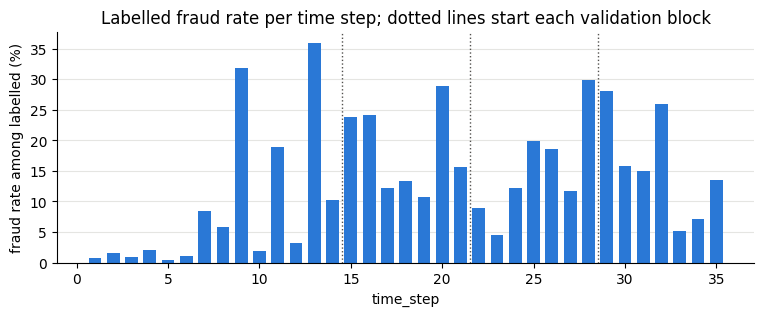

fraud rate range: 0.43% to 35.97% (85x swing)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from validation import DEFAULT_FOLDS, rolling_origin_folds, evaluate, summarise
from models import (logreg_fit_predict, rf_fit_predict, LGBMFitPredict, time_order,
                    adversarial_auc, single_feature_adversarial_auc, PERIOD_ID_THRESHOLD)

RAW = [c for c in train.columns if c.startswith("feat_")]
lab = train["label"].notna()

# Palette: validated categorical slots 1-3 (blue, orange, aqua) from the dataviz reference.
C1, C2, C3, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e"

for fold, tr, va in rolling_origin_folds(train["time_step"]):
    print(f"{fold.name:28s} labelled train={int((tr & lab).sum()):6,}  labelled val={int((va & lab).sum()):6,}")

rate = train[lab].groupby("time_step")["label"].agg(n="size", fraud_rate="mean")
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(rate.index, rate["fraud_rate"] * 100, color=C1, width=0.7)
for lo, hi, vlo, vhi in DEFAULT_FOLDS:
    ax.axvline(vlo - 0.5, color=MUTED, lw=1, ls=":")
ax.set(xlabel="time_step", ylabel="fraud rate among labelled (%)",
       title="Labelled fraud rate per time step; dotted lines start each validation block")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e5e5e2"); ax.set_axisbelow(True)
plt.show()
print(f"fraud rate range: {rate.fraud_rate.min():.2%} to {rate.fraud_rate.max():.2%} "
      f"({rate.fraud_rate.max() / rate.fraud_rate.min():.0f}x swing)")

## 6. Baselines on the raw 165 features

Three model families through the same folds. Random Forest is the strongest published
baseline on this data (Weber et al. 2019); LightGBM is the workhorse for everything
after. Only labelled rows enter fitting and scoring. LightGBM picks its round count on
the most recent 15% of each training window, then refits on the whole window.

Rows are sorted by `time_step` first so that "most recent" is well defined.

In [13]:
X_raw, y_lab, ts_lab = time_order(train.loc[lab, RAW], train.loc[lab, "label"], train.loc[lab, "time_step"],
                                  time_step=train.loc[lab, "time_step"])

lgbm_raw = LGBMFitPredict()
results, per_step = [], []
for name, fn, seeds in [("logreg", logreg_fit_predict, (0,)),
                        ("rf", rf_fit_predict, (0, 1, 2)),
                        ("lgbm_raw", lgbm_raw, (0, 1, 2))]:
    r, s = evaluate(fn, X_raw, y_lab, ts_lab, seeds=seeds, name=name, verbose=False)
    print(f"{name:10s} AUC={r.auc_pooled.mean():.4f} ± {r.auc_pooled.std():.4f}   "
          f"step-mean={r.auc_step_mean.mean():.4f}   PR-AUC={r.pr_auc.mean():.4f}")
    results.append(r); s.columns = [f"{name}|{c}" for c in s.columns]; per_step.append(s)

cv_raw = pd.concat(results)
cv_raw.to_csv("artifacts/cv_raw_baselines.csv", index=False)
pd.concat(per_step, axis=1).to_csv("artifacts/cv_raw_baselines_per_step.csv")
summarise(cv_raw)

/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cheepheng/bt4012_fraudulent_cryp

/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cheepheng/bt4012_fraudulent_cryptocurrency_transactions/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


logreg     AUC=0.9033 ± 0.0437   step-mean=0.9103   PR-AUC=0.6241


rf         AUC=0.9651 ± 0.0453   step-mean=0.9681   PR-AUC=0.9413


lgbm_raw   AUC=0.9737 ± 0.0241   step-mean=0.9735   PR-AUC=0.9279


auc_pooled         auc_step_mean         auc_gap          pr_auc  \
               mean     std          mean     std    mean     std    mean   
model                                                                       
lgbm_raw     0.9737  0.0241        0.9735  0.0224  0.0002  0.0023  0.9279   
logreg       0.9033  0.0437        0.9103  0.0305 -0.0070  0.0173  0.6241   
rf           0.9651  0.0453        0.9681  0.0394 -0.0029  0.0069  0.9413   

                  
             std  
model             
lgbm_raw  0.0461  
logreg    0.1083  
rf        0.0631

### 6b. Raw features that identify the period

A classifier told to separate labelled train rows from test rows (adversarial
validation) scores AUC 1.0 on the raw features. To find out which columns are
responsible, each feature is tested **alone** with a small tree model. The
distribution has a gap: a handful of columns score above 0.99, the next one 0.935.
Everything above 0.95 is treated as a *period identifier* and removed from every model.

The table explains why: their per-step median is monotone in `time_step`, three of them
almost exactly linear, and 99% of their test values lie outside the training range. A
tree can split on them to learn *when* a transaction happened, and on the test period
every row lands in the newest leaf. Section 9 measures what removing them costs on CV.

period identifiers (single-feature adversarial AUC > 0.95): ['feat_136', 'feat_101', 'feat_103', 'feat_100', 'feat_139', 'feat_137']
next five: {'feat_2': 0.935, 'feat_106': 0.903, 'feat_107': 0.876, 'feat_109': 0.876, 'feat_142': 0.853}


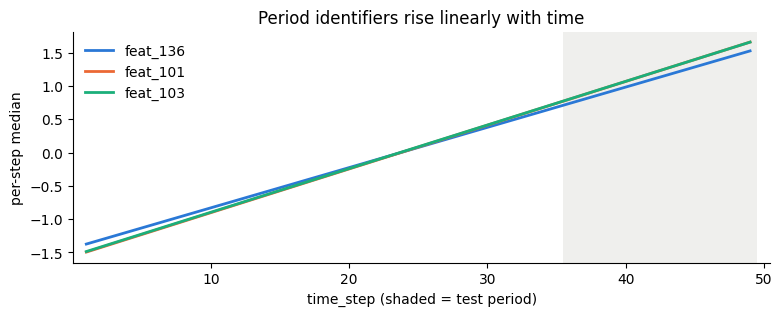

,single_feature_adversarial_auc,spearman_with_time,test_share_outside_train_range
feat_136,1.000,0.994,0.000
feat_101,0.999,0.998,0.995
feat_103,0.999,0.996,0.994
feat_100,0.999,0.994,0.992
feat_139,0.992,0.962,0.000
feat_137,0.990,0.901,0.000


In [14]:
sf_raw = single_feature_adversarial_auc(train.loc[lab, RAW], test[RAW])
PROXY = sf_raw[sf_raw > PERIOD_ID_THRESHOLD].index.tolist()
RAW_CLEAN = [c for c in RAW if c not in PROXY]
sf_raw.to_csv("artifacts/single_feature_adversarial_auc_raw.csv")
print(f"period identifiers (single-feature adversarial AUC > {PERIOD_ID_THRESHOLD}): {PROXY}")
print("next five:", sf_raw.drop(PROXY).head(5).round(3).to_dict())

both = pd.concat([train[RAW + ["time_step"]], test[RAW + ["time_step"]]])
proxy_tbl = pd.DataFrame({
    "single_feature_adversarial_auc": sf_raw[PROXY],
    "spearman_with_time": both[PROXY].corrwith(both["time_step"], method="spearman"),
    "test_share_outside_train_range": {c: ((test[c] < train[c].min()) | (test[c] > train[c].max())).mean() for c in PROXY},
})

fig, ax = plt.subplots(figsize=(9, 3))
med = both.groupby("time_step")[PROXY[:3]].median()
for col, c in zip(PROXY[:3], (C1, C2, C3)):
    ax.plot(med.index, med[col], color=c, lw=2, label=col)
ax.axvspan(35.5, 49.5, color="#e5e5e2", alpha=0.6, lw=0)
ax.set(xlabel="time_step (shaded = test period)", ylabel="per-step median", title="Period identifiers rise linearly with time")
ax.legend(frameon=False, loc="upper left"); ax.spines[["top", "right"]].set_visible(False); ax.margins(x=0.02)
plt.show()
proxy_tbl.round(3)

In [15]:
# Which raw features to summarise over neighbours: top-20 by LightGBM gain on the
# largest CV training window (steps 1-28), so the choice never sees steps 29-35. Time proxies excluded.
import lightgbm as lgb
from models import LGBM_PARAMS
m28 = (ts_lab <= 28).to_numpy()
imp_model = lgb.LGBMClassifier(**{**LGBM_PARAMS, "n_estimators": lgbm_raw.median_best_iter, "random_state": 0})
imp_model.fit(X_raw.loc[m28, RAW_CLEAN], y_lab[m28].astype(int))
importance_raw = pd.Series(imp_model.booster_.feature_importance("gain"), index=RAW_CLEAN).sort_values(ascending=False)
importance_raw.to_csv("artifacts/lgbm_importance_raw_1to28.csv")
TOP = importance_raw.index[:20].tolist()
print("aggregate these over neighbours:", TOP)

aggregate these over neighbours: ['feat_53', 'feat_55', 'feat_47', 'feat_90', 'feat_5', 'feat_2', 'feat_163', 'feat_132', 'feat_41', 'feat_14', 'feat_59', 'feat_18', 'feat_58', 'feat_46', 'feat_142', 'feat_23', 'feat_89', 'feat_43', 'feat_22', 'feat_80']


## 7. Graph features

Two measured facts shape this section:

* **Edges never cross the train/test boundary**, so each period is its own graph and
  every feature is computed inside one period. No label can travel through the graph
  into the test set.
* **The test file holds only the labelled test-period nodes.** The other 46,668
  test-period transactions are present in the edge list (ids and edges) but have no
  feature vector. So *topology* is fully observed on both sides, but neighbour
  *feature* aggregates on test can only see labelled neighbours.

The cell below verifies the second fact: every dangling edge touches a test node, never
a train node. That is what makes the coverage feature (`g_unk_*`, neighbours without a
feature vector) mean the same thing on both sides.

`graph_features.py` therefore builds two families:

| Family | Computed on | Parity |
|---|---|---|
| topology: degrees, coverage, component size, DAG depth/height, PageRank | all edges of the period, including nodes without features | exact |
| aggregates: mean/max/std of the top-20 features over predecessors, successors, 1-hop and 2-hop, plus node-minus-neighbour deltas | neighbours with features only | on train, computed twice: over **all** train nodes ("full") and over **labelled** nodes only ("lab", mirroring test) |

In [16]:
from graph_features import period_edges, build_period_features, shuffle_edges

train_ids, test_ids = pd.Index(train["txId"]), pd.Index(test["txId"])
a, b = edges["txId1"].isin(train_ids), edges["txId2"].isin(train_ids)
c, d = edges["txId1"].isin(test_ids), edges["txId2"].isin(test_ids)
dangling = ~((a | c) & (b | d))
print(f"train-train {int((a & b).sum()):,}   test-test {int((c & d).sum()):,}   train-test {int(((a & d) | (b & c)).sum()):,}")
print(f"dangling edges {int(dangling.sum()):,}: touching train {int((dangling & (a | b)).sum()):,}, "
      f"touching test {int((dangling & (c | d)).sum()):,}, neither {int((dangling & ~(a | b | c | d)).sum()):,}")
assert (dangling & (a | b)).sum() == 0, "a dangling edge touches train: coverage feature would not be comparable"

tr_idx, te_idx = train.set_index("txId"), test.set_index("txId")
G = {
    "full": build_period_features(edges, train_ids, "train", tr_idx[TOP]),
    "lab":  build_period_features(edges, train_ids, "train", tr_idx.loc[lab.to_numpy(), TOP]),
    "test": build_period_features(edges, train_ids, "test",  te_idx[TOP]),
}
GCOLS = G["test"].columns.tolist()
TOPO = [c for c in GCOLS if c.startswith("g_")]
for k, v in G.items():
    v.to_pickle(f"artifacts/graph_feats_{k}.pkl")
print({k: v.shape for k, v in G.items()}, f"-> {len(GCOLS)} graph columns ({len(TOPO)} topology)")

# Parity check on topology: labelled train nodes vs test nodes
parity = pd.DataFrame({"train (labelled, lab view)": G["lab"].reindex(train.loc[lab, "txId"])[TOPO].mean(),
                       "test": G["test"][TOPO].mean()}).round(3)
parity

train-train 163,194   test-test 12,724   train-test 0
dangling edges 58,437: touching train 0, touching test 24,245, neither 34,192


{'full': (141772, 194), 'lab': (31235, 194), 'test': (15329, 194)} -> 194 graph columns (12 topology)


,"train (labelled, lab view)",test
g_in_deg,1.763,2.018
g_out_deg,1.102,1.224
g_deg,2.866,3.242
g_in_out_ratio,1.857,1.851
g_unk_pred,0.998,1.188
g_unk_succ,0.337,0.394
g_unk_share,0.369,0.391
g_wcc_size,4780.146,4954.891
g_wcc_log,8.406,8.461
g_dag_depth,11.824,5.273


## 8. Adversarial validation of the graph features

The same test, applied to the engineered columns. The cleaned raw features still
separate the periods well (AUC 0.997): that is genuine temporal drift in features such
as `feat_2`, not a leak, and it is the floor the model has to live with. So graph columns
are held to the same single-feature rule as the raw ones: anything that identifies the
period on its own (AUC above 0.95) is dropped. Component size goes first, because
components never span time steps, so a component's size is its time step's size.

In [17]:
import json

def matrix(view):
    g = G[view].reindex(train.loc[lab, "txId"]).reset_index(drop=True)
    return pd.concat([train.loc[lab, RAW].reset_index(drop=True), g], axis=1)

Xtr_full, Xtr_lab = matrix("full"), matrix("lab")
Xte = pd.concat([test[RAW].reset_index(drop=True), G["test"].reindex(test["txId"]).reset_index(drop=True)], axis=1)
AGG = [c for c in GCOLS if c not in TOPO]

sf_graph = single_feature_adversarial_auc(Xtr_lab, Xte, GCOLS)
G_DROP = sf_graph[sf_graph > PERIOD_ID_THRESHOLD].index.tolist()
GKEEP = [c for c in GCOLS if c not in G_DROP]
TOPO_KEEP, AGG_KEEP = [c for c in TOPO if c in GKEEP], [c for c in AGG if c in GKEEP]
sf_graph.to_csv("artifacts/single_feature_adversarial_auc_graph.csv")
print(f"graph period identifiers dropped: {G_DROP}")
print("next five:", sf_graph.drop(G_DROP).head(5).round(3).to_dict())

av_groups = {}
for name, cols in [("raw (all 165)", RAW), ("raw without period identifiers", RAW_CLEAN), ("period identifiers only", PROXY),
                   ("topology, all", TOPO), ("topology, kept", TOPO_KEEP), ("aggregates (lab view)", AGG_KEEP)]:
    auc, imp = adversarial_auc(Xtr_lab[cols], Xte[cols])
    av_groups[name] = {"multivariate AV AUC": round(auc, 4), "top-3": ", ".join(imp.index[:3])}
json.dump({"groups": av_groups, "graph_dropped": G_DROP, "raw_dropped": PROXY}, open("artifacts/adversarial_validation.json", "w"), indent=1)
pd.DataFrame(av_groups).T

graph period identifiers dropped: ['g_wcc_size', 'g_wcc_log']
next five: {'nb2_mean_feat_2': 0.846, 'g_pagerank': 0.835, 'nb1_mean_feat_2': 0.821, 'nb2_mean_feat_142': 0.813, 'nb1_mean_feat_142': 0.807}


,multivariate AV AUC,top-3
raw (all 165),1.0,"feat_101, feat_103, feat_136"
raw without period identifiers,0.9966,"feat_2, feat_106, feat_109"
period identifiers only,1.0,"feat_101, feat_103, feat_136"
"topology, all",1.0,"g_wcc_size, g_wcc_log, g_pagerank"
"topology, kept",0.9163,"g_pagerank, g_dag_depth, g_in_deg"
aggregates (lab view),0.9593,"nb2_mean_feat_2, nb2_mean_feat_142, nb1_mean_feat_2"


## 9. Raw + graph model, and does the graph help at all?

Same LightGBM, same folds, same three seeds. Six configurations (the all-165 reference, the cleaned raw set, then topology, aggregates and all kept graph columns on top of it, in both train views), then an
**edge-shuffle ablation**: destinations are permuted within each period, the graph
features are rebuilt on the rewired graph and the model retrained. If shuffled edges score
the same, the graph features carry no signal beyond degree-like counts.

In [18]:
def run_cfg(name, Xtr, cols, fp=None):
    fp = fp or LGBMFitPredict()
    X, y, ts = time_order(Xtr[cols], train.loc[lab, "label"].reset_index(drop=True),
                          train.loc[lab, "time_step"].reset_index(drop=True),
                          time_step=train.loc[lab, "time_step"].reset_index(drop=True))
    r, s = evaluate(fp, X, y, ts, seeds=(0, 1, 2), name=name, verbose=False)
    print(f"{name:34s} AUC={r.auc_pooled.mean():.4f} ± {r.auc_pooled.std():.4f}   "
          f"step-mean={r.auc_step_mean.mean():.4f}   PR-AUC={r.pr_auc.mean():.4f}")
    s.columns = [f"{name}|{c}" for c in s.columns]
    return r, s, fp

configs = {
    "lgbm_raw (all 165, reference)":    (Xtr_lab,  RAW),
    "lgbm_raw_clean":                   (Xtr_lab,  RAW_CLEAN),
    "lgbm_raw_clean+topo":              (Xtr_lab,  RAW_CLEAN + TOPO_KEEP),
    "lgbm_raw_clean+agg (lab view)":    (Xtr_lab,  RAW_CLEAN + AGG_KEEP),
    "lgbm_raw_clean+graph (lab view)":  (Xtr_lab,  RAW_CLEAN + GKEEP),
    "lgbm_raw_clean+graph (full view)": (Xtr_full, RAW_CLEAN + GKEEP),
}
cv_rows, cv_steps, fitters = [], [], {}
for name, (Xtr, cols) in configs.items():
    r, s, fp = run_cfg(name, Xtr, cols); cv_rows.append(r); cv_steps.append(s); fitters[name] = fp

# ablation: rewired graph, labelled view, pruned columns
G_shuf = build_period_features(shuffle_edges(edges, train_ids, seed=0), train_ids, "train", tr_idx.loc[lab.to_numpy(), TOP])
Xtr_shuf = pd.concat([train.loc[lab, RAW].reset_index(drop=True),
                      G_shuf.reindex(train.loc[lab, "txId"]).reset_index(drop=True)], axis=1)
r, s, _ = run_cfg("ABLATION shuffled edges (lab view)", Xtr_shuf, RAW_CLEAN + GKEEP)
cv_rows.append(r); cv_steps.append(s)

cv_graph = pd.concat(cv_rows); cv_graph.to_csv("artifacts/cv_graph.csv", index=False)
cv_graph_steps = pd.concat(cv_steps, axis=1); cv_graph_steps.to_csv("artifacts/cv_graph_per_step.csv")
summarise(cv_graph)

lgbm_raw (all 165, reference)      AUC=0.9737 ± 0.0241   step-mean=0.9735   PR-AUC=0.9279


lgbm_raw_clean                     AUC=0.9726 ± 0.0272   step-mean=0.9735   PR-AUC=0.9316


lgbm_raw_clean+topo                AUC=0.9725 ± 0.0278   step-mean=0.9738   PR-AUC=0.9325


lgbm_raw_clean+agg (lab view)      AUC=0.9649 ± 0.0336   step-mean=0.9659   PR-AUC=0.9170


lgbm_raw_clean+graph (lab view)    AUC=0.9680 ± 0.0318   step-mean=0.9689   PR-AUC=0.9297


lgbm_raw_clean+graph (full view)   AUC=0.9691 ± 0.0296   step-mean=0.9701   PR-AUC=0.9233


ABLATION shuffled edges (lab view) AUC=0.9741 ± 0.0266   step-mean=0.9749   PR-AUC=0.9372


auc_pooled         auc_step_mean          \
                                         mean     std          mean     std   
model                                                                         
ABLATION shuffled edges (lab view)     0.9741  0.0266        0.9749  0.0245   
lgbm_raw (all 165, reference)          0.9737  0.0241        0.9735  0.0224   
lgbm_raw_clean                         0.9726  0.0272        0.9735  0.0249   
lgbm_raw_clean+agg (lab view)          0.9649  0.0336        0.9659  0.0310   
lgbm_raw_clean+graph (full view)       0.9691  0.0296        0.9701  0.0278   
lgbm_raw_clean+graph (lab view)        0.9680  0.0318        0.9689  0.0298   
lgbm_raw_clean+topo                    0.9725  0.0278        0.9738  0.0252   

                                   auc_gap          pr_auc          
                                      mean     std    mean     std  
model                                                               
ABLATION shuffled edges (lab view) -0.0008  0.0024  0.9372  0.0517  
lgbm_raw (all 165, reference)       0.0002  0.0023  0.9279  0.0461  
lgbm_raw_clean                     -0.0009  0.0025  0.9316  0.0509  
lgbm_raw_clean+agg (lab view)      -0.0010  0.0028  0.9170  0.0525  
lgbm_raw_clean+graph (full view)   -0.0009  0.0018  0.9233  0.0480  
lgbm_raw_clean+graph (lab view)    -0.0009  0.0022  0.9297  0.0526  
lgbm_raw_clean+topo                -0.0013  0.0027  0.9325  0.0501

best by CV among configurations without period identifiers: lgbm_raw_clean


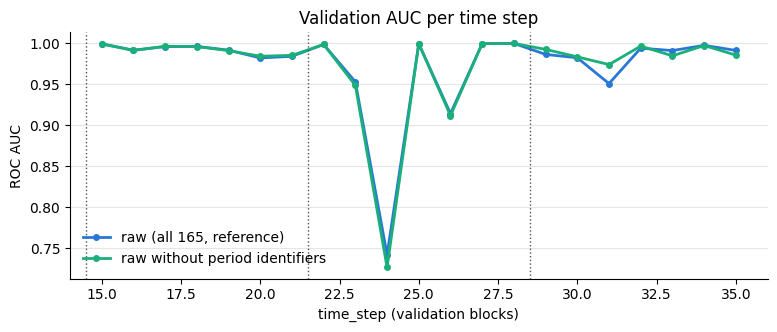

In [19]:
# Per-step validation AUC: raw vs the best graph configuration (mean over seeds)
eligible = cv_graph[~cv_graph.model.str.startswith("ABLATION") & ~cv_graph.model.str.contains("reference")]
best_cfg = eligible.groupby("model").auc_pooled.mean().idxmax()
print("best by CV among configurations without period identifiers:", best_cfg)

def step_curve(name):
    cols = [c for c in cv_graph_steps.columns if c.startswith(name + "|")]
    return cv_graph_steps[cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 3.2))
curves = [("raw (all 165, reference)", step_curve("lgbm_raw (all 165, reference)"), C1),
          ("raw without period identifiers", step_curve("lgbm_raw_clean"), C3)]
if best_cfg != "lgbm_raw_clean":
    curves.append((best_cfg, step_curve(best_cfg), C2))
for label, series, col in curves:
    ax.plot(series.index, series.values, color=col, lw=2, marker="o", ms=4, label=label)
for lo, hi, vlo, vhi in DEFAULT_FOLDS:
    ax.axvline(vlo - 0.5, color=MUTED, lw=1, ls=":")
ax.set(xlabel="time_step (validation blocks)", ylabel="ROC AUC", title="Validation AUC per time step")
ax.legend(frameon=False, loc="lower left"); ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e2"); ax.set_axisbelow(True)
plt.show()

### 9b. Boosting rounds and the class weight

Every LightGBM above chose its round count by early stopping on the most recent 15% of
the training window and weighted the illicit class by the inverse base rate. Both are
conventional, and both cost AUC here. ROC AUC is rank-based, so the class weight cannot
improve the metric; it only reshapes the trees. And the stopper tail has a different base
rate from the next period (the fraud rate swings 0.4% to 36% between steps), so the round
count it picks fits the tail, not the future. The cell holds the features fixed (cleaned raw
set) and varies only these two choices, three seeds each.

In [20]:
from models import lgbm_fixed_fit_predict

rounds_rows, rounds_steps = [], []
for name, fp in [("lgbm_raw_clean, fixed 600, pos_weight", lgbm_fixed_fit_predict(600, pos_weight=True)),
                 ("lgbm_raw_clean, fixed 600, unweighted", lgbm_fixed_fit_predict(600)),
                 *[(f"lgbm_raw_clean, fixed {n}, unweighted", lgbm_fixed_fit_predict(n)) for n in (150, 200, 300, 400)]]:
    r, s, _ = run_cfg(name, Xtr_lab, RAW_CLEAN, fp=fp); rounds_rows.append(r); rounds_steps.append(s)

cv_graph = pd.concat([cv_graph] + rounds_rows); cv_graph.to_csv("artifacts/cv_graph.csv", index=False)
cv_graph_steps = pd.concat([cv_graph_steps] + rounds_steps, axis=1); cv_graph_steps.to_csv("artifacts/cv_graph_per_step.csv")
cv_rounds = pd.concat([cv_graph[cv_graph.model == "lgbm_raw_clean"]] + rounds_rows)
cv_rounds.to_csv("artifacts/cv_lgbm_rounds.csv", index=False)

tbl = cv_rounds.groupby("model")[["auc_pooled", "auc_step_mean", "pr_auc"]].mean()
tbl["auc fold 22-28"] = cv_rounds[cv_rounds.fold.str.contains("22-28")].groupby("model").auc_pooled.mean()
tbl = tbl.rename(index={"lgbm_raw_clean": "lgbm_raw_clean (early stop + pos_weight, as above)"}).sort_values("auc_pooled", ascending=False)
FIXED_ROUNDS = 300
print(f"chosen: {FIXED_ROUNDS} fixed rounds, unweighted (plateau from 250; 400 is already lower on the hard fold)")
tbl.round(4)

lgbm_raw_clean, fixed 600, pos_weight AUC=0.9734 ± 0.0324   step-mean=0.9738   PR-AUC=0.9471


lgbm_raw_clean, fixed 600, unweighted AUC=0.9797 ± 0.0232   step-mean=0.9788   PR-AUC=0.9504


lgbm_raw_clean, fixed 150, unweighted AUC=0.9765 ± 0.0258   step-mean=0.9767   PR-AUC=0.9443


lgbm_raw_clean, fixed 200, unweighted AUC=0.9806 ± 0.0210   step-mean=0.9796   PR-AUC=0.9485


lgbm_raw_clean, fixed 300, unweighted AUC=0.9819 ± 0.0197   step-mean=0.9806   PR-AUC=0.9507


lgbm_raw_clean, fixed 400, unweighted AUC=0.9809 ± 0.0214   step-mean=0.9799   PR-AUC=0.9505
chosen: 300 fixed rounds, unweighted (plateau from 250; 400 is already lower on the hard fold)


,auc_pooled,auc_step_mean,pr_auc,auc fold 22-28
model,,,,
"lgbm_raw_clean, fixed 300, unweighted",0.9819,0.9806,0.9507,0.9558
"lgbm_raw_clean, fixed 400, unweighted",0.9809,0.9799,0.9505,0.9525
"lgbm_raw_clean, fixed 200, unweighted",0.9806,0.9796,0.9485,0.9527
"lgbm_raw_clean, fixed 600, unweighted",0.9797,0.9788,0.9504,0.9489
"lgbm_raw_clean, fixed 150, unweighted",0.9765,0.9767,0.9443,0.9423
"lgbm_raw_clean, fixed 600, pos_weight",0.9734,0.9738,0.9471,0.9304
"lgbm_raw_clean (early stop + pos_weight, as above)",0.9726,0.9735,0.9316,0.9368


## 10. Final fit and first submissions

The final model is the best CV configuration **among those without period
identifiers**. The all-165 reference is not eligible even when its CV number is a
fraction higher: rolling CV validates 7 steps past the training window, the test set
runs 14 steps past it, and on those columns almost every test value is outside the range
the trees ever split on. CV cannot price that risk, so the rule is set before seeing the
leaderboard.

Two files are written: the primary submission and, as a controlled experiment, the same
model with the period identifiers kept. Their leaderboard gap is the only direct
measurement of the extrapolation cost, and it costs one of the three daily uploads.

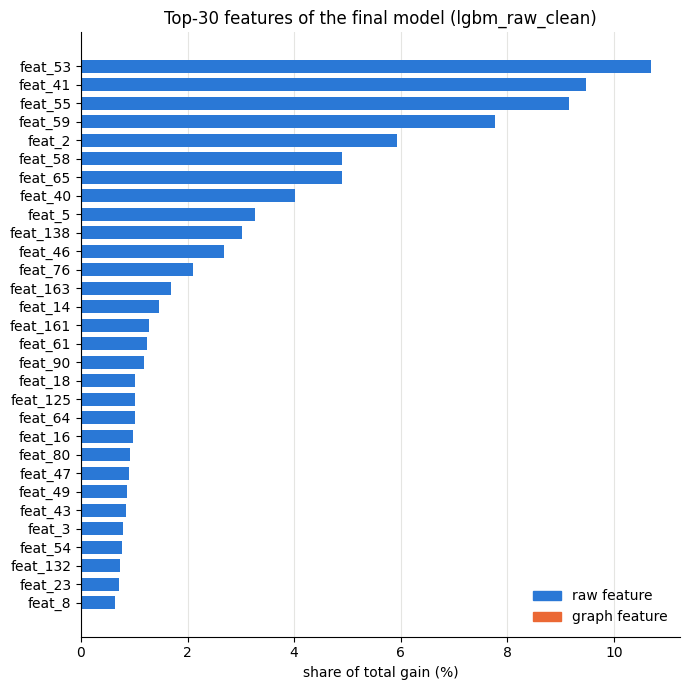

graph features in top-30: 0; share of gain from graph features: 0.0%
| 2026-09-26 | sub_01_lgbm_clean.csv | lgbm_raw_clean | 159 | 175 | 0.9726 | 0.9735 | 0.9316 | _pending_ |
| 2026-09-26 | sub_02_lgbm_raw_with_period_ids.csv | lgbm_raw (all 165, reference) | 165 | 176 | 0.9737 | 0.9735 | 0.9279 | _pending_ |

wrote submissions/sub_01_lgbm_clean.csv (primary) and submissions/sub_02_lgbm_raw_with_period_ids.csv (comparison); upload at https://www.kaggle.com/competitions/bt-4012-competition-2026/submissions and fill in the public LB column in results.md


In [21]:
from pathlib import Path
from datetime import date

def fit_final(Xtr, cols, n_iter):
    ytr = train.loc[lab, "label"].to_numpy().astype(int)
    m = lgb.LGBMClassifier(**{**LGBM_PARAMS, "n_estimators": n_iter, "random_state": 0,
                              "scale_pos_weight": (ytr == 0).sum() / (ytr == 1).sum()})
    return m.fit(Xtr[cols], ytr)

def write_submission(pred, name):
    sub = sample_submission.copy(); sub["target"] = pred
    assert len(sub) == 15_329
    assert (sub["index"].to_numpy() == sample_submission["index"].to_numpy()).all()
    assert sub["target"].between(0, 1).all() and sub["target"].notna().all()
    Path("submissions").mkdir(exist_ok=True)
    path = Path("submissions") / name; sub.to_csv(path, index=False); return path

Xtr_best, cols_best = configs[best_cfg]
n_iter = fitters[best_cfg].median_best_iter
final = fit_final(Xtr_best, cols_best, n_iter)
p1 = write_submission(final.predict_proba(Xte[cols_best])[:, 1], "sub_01_lgbm_clean.csv")

ref = "lgbm_raw (all 165, reference)"
n_iter_ref = fitters[ref].median_best_iter
final_ref = fit_final(*configs[ref], n_iter_ref)
p2 = write_submission(final_ref.predict_proba(Xte[RAW])[:, 1], "sub_02_lgbm_raw_with_period_ids.csv")

imp = pd.Series(final.booster_.feature_importance("gain"), index=cols_best).sort_values(ascending=False)
imp_share = imp / imp.sum()
fig, ax = plt.subplots(figsize=(7, 7))
top30 = imp_share.head(30)[::-1]
ax.barh(top30.index, top30.values * 100, color=[C2 if c in GCOLS else C1 for c in top30.index], height=0.7)
ax.set(xlabel="share of total gain (%)", title=f"Top-30 features of the final model ({best_cfg})")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C1), plt.Rectangle((0, 0), 1, 1, color=C2)],
          labels=["raw feature", "graph feature"], frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", color="#e5e5e2"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
gshare = imp_share[[c for c in cols_best if c in GCOLS]].sum() if any(c in GCOLS for c in cols_best) else 0.0
print(f"graph features in top-30: {sum(c in GCOLS for c in top30.index)}; share of gain from graph features: {gshare:.1%}")

def ledger_line(path, cfg, cols, n):
    r = cv_graph[cv_graph.model == cfg]
    return (f"| {date.today()} | {path.name} | {cfg} | {len(cols)} | {n} | "
            f"{r.auc_pooled.mean():.4f} | {r.auc_step_mean.mean():.4f} | {r.pr_auc.mean():.4f} | _pending_ |")
lines = [ledger_line(p1, best_cfg, cols_best, n_iter), ledger_line(p2, ref, RAW, n_iter_ref)]
ledger = Path("results.md"); txt = ledger.read_text()
for ln in lines:
    if ln.split("|")[2].strip() not in txt:
        txt += ln + "\n"
ledger.write_text(txt)
print("\n".join(lines))
print(f"\nwrote {p1} (primary) and {p2} (comparison); upload at "
      "https://www.kaggle.com/competitions/bt-4012-competition-2026/submissions and fill in the public LB column in results.md")

### 10b. Third submission: fixed rounds, unweighted

Section 9b changes the primary model. `sub_03` is the cleaned raw set with 300 fixed
rounds and no class weight, and it replaces `sub_01` as the primary upload. `sub_01` and
`sub_02` stay on disk and in the ledger, so the leaderboard can price each change on its
own: period identifiers (`sub_02` vs `sub_01`) and rounds/weighting (`sub_03` vs `sub_01`).
Graph features are not in this model: sections 9 and 9b show none of them beat the cleaned
raw set on rolling CV, and the shuffled-edge ablation scores the same as the real graph.

In [22]:
fixed_final = lgb.LGBMClassifier(**{**LGBM_PARAMS, "n_estimators": FIXED_ROUNDS, "random_state": 0}).fit(
    Xtr_lab[RAW_CLEAN], train.loc[lab, "label"].to_numpy().astype(int))
p3 = write_submission(fixed_final.predict_proba(Xte[RAW_CLEAN])[:, 1], "sub_03_lgbm_clean_fixed300_unweighted.csv")
cfg3 = f"lgbm_raw_clean, fixed {FIXED_ROUNDS}, unweighted"
line3 = ledger_line(p3, cfg3, RAW_CLEAN, FIXED_ROUNDS)
txt = ledger.read_text()
if p3.name not in txt:
    ledger.write_text(txt + line3 + "\n")
print(line3)

from scipy.stats import spearmanr
s1 = pd.read_csv(p1)["target"]; s3 = pd.read_csv(p3)["target"]
print(f"\nSpearman between sub_01 and sub_03 rankings: {spearmanr(s1, s3).correlation:.4f}")
print(f"wrote {p3} (primary upload). Fill in the public LB column of results.md after uploading.")

| 2026-09-26 | sub_03_lgbm_clean_fixed300_unweighted.csv | lgbm_raw_clean, fixed 300, unweighted | 159 | 300 | 0.9819 | 0.9806 | 0.9507 | _pending_ |

Spearman between sub_01 and sub_03 rankings: 0.9607
wrote submissions/sub_03_lgbm_clean_fixed300_unweighted.csv (primary upload). Fill in the public LB column of results.md after uploading.


## 11. Step 2 — temporal drift: a test-like fold and the cross-step gap

The public leaderboard scored sub_03 at 0.945 against a rolling-CV AUC of 0.982. Our folds
validate 7 steps ahead; the test window runs 14 steps ahead. This section adds a fourth fold
with the test's horizon (train 1–21 → val 22–35) and a diagnostic, the **gap** = pooled AUC
minus the mean of per-step AUCs. A negative gap means the model ranks well *inside* each step
but its scores are not comparable *across* steps, which the pooled competition metric punishes.

Three score-level corrections are then applied to the same validation predictions:
within-step percentile ranking, EM prior estimation with Bayes adjustment (Saerens et al. 2002),
and BBSE (Lipton et al. 2018), plus an oracle that adjusts with the true per-step prior to show
the ceiling.

train 1-14 -> val 15-21: validates up to 7 steps past training
train 1-21 -> val 22-28: validates up to 7 steps past training
train 1-28 -> val 29-35: validates up to 7 steps past training
train 1-21 -> val 22-35: validates up to 14 steps past training


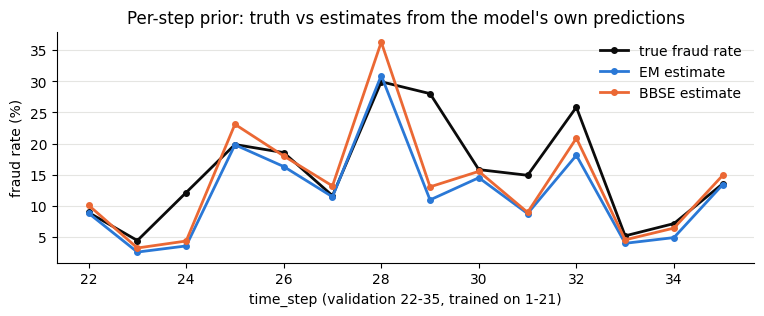

prior estimate MAE vs truth: EM 0.0223, BBSE 0.0292, raw mean prediction 0.0245


,per_step_mean,pooled_raw,within_step_rank,em_prior,oracle_true_prior
fold,,,,,
train 1-14 | val 15-21,0.9932,0.9933,0.9768,0.9933,0.9935
train 1-21 | val 22-28,0.9534,0.9558,0.9238,0.9316,0.9547
train 1-21 | val 22-35,0.9221,0.8961,0.8587,0.8911,0.9146
train 1-28 | val 29-35,0.9954,0.9966,0.9760,0.9962,0.9964


In [23]:
from validation import FOLDS_WITH_HORIZON, HORIZON_FOLD, rolling_origin_folds, per_step_auc
from models import lgbm_fixed_fit_predict, bagged_fit_predict, rf_fit_predict_w, rank_blend_fit_predict
from drift import recency_weights, StepNormalizer, rank_within_step, prior_shift_correct, adjust_scores, bbse_prior
from sklearn.metrics import roc_auc_score

L = train.loc[lab].reset_index(drop=True); y2, ts2 = L["label"], L["time_step"]
lgbm300 = lgbm_fixed_fit_predict(FIXED_ROUNDS)

def fold_table(r):
    f = r.groupby("fold")[["auc_pooled", "auc_gap"]].mean()
    std = [k for k in f.index if not k.endswith("22-35")]; hor = [k for k in f.index if k.endswith("22-35")]
    return dict(auc_3fold=f.loc[std, "auc_pooled"].mean(), auc_hard=f.loc[[k for k in std if "22-28" in k], "auc_pooled"].mean(),
                auc_horizon=f.loc[hor, "auc_pooled"].mean(), gap_horizon=f.loc[hor, "auc_gap"].mean(), pr_auc=r.pr_auc.mean())

def run2(name, X, fp=lgbm300, seeds=(0, 1, 2), **kw):
    r, s = evaluate(fp, X, y2, ts2, folds=FOLDS_WITH_HORIZON, seeds=seeds, name=name, verbose=False, **kw)
    d = {"config": name, **fold_table(r)}
    print(f"{name:46s} 3-fold={d['auc_3fold']:.4f}  hard={d['auc_hard']:.4f}  horizon={d['auc_horizon']:.4f}  gap={d['gap_horizon']:+.4f}  PR={d['pr_auc']:.4f}")
    return r, s, d

for lo, hi, vlo, vhi in FOLDS_WITH_HORIZON:
    print(f"train {lo}-{hi} -> val {vlo}-{vhi}: validates up to {vhi - hi} steps past training")

rows, prior_rows = [], []
for fold, tr, va in rolling_origin_folds(ts2, FOLDS_WITH_HORIZON):
    for seed in (0, 1, 2):
        p = lgbm300(L.loc[tr, RAW_CLEAN], y2[tr].to_numpy().astype(int), L.loc[va, RAW_CLEAN], seed)
        yv, tv, prior_tr = y2[va].to_numpy().astype(int), ts2[va].to_numpy(), y2[tr].mean()
        p_em, pri = prior_shift_correct(p, tv, prior_tr)
        true = pd.Series(yv).groupby(tv).mean(); true.index = true.index.astype(int)
        p_or = p.copy()
        for st in np.unique(tv):
            m = tv == st; p_or[m] = adjust_scores(p[m], prior_tr, float(np.clip(true[int(st)], 1e-3, 1 - 1e-3)))
        cut = np.quantile(ts2[tr], 0.85); cal = tr & (ts2 > cut).to_numpy()
        p_cal = lgbm300(L.loc[tr & ~cal, RAW_CLEAN], y2[tr & ~cal].to_numpy().astype(int), L.loc[cal, RAW_CLEAN], seed)
        bb = {int(st): bbse_prior(p[tv == st], y2[cal].to_numpy().astype(int), p_cal) for st in np.unique(tv)}
        rows.append(dict(fold=fold.name, seed=seed, per_step_mean=per_step_auc(yv, p, tv).mean(), pooled_raw=roc_auc_score(yv, p),
                         within_step_rank=roc_auc_score(yv, rank_within_step(p, tv)), em_prior=roc_auc_score(yv, p_em),
                         oracle_true_prior=roc_auc_score(yv, p_or)))
        for st in true.index:
            prior_rows.append(dict(fold=fold.name, seed=seed, step=st, true=true[st], em=pri[st], bbse=bb[st], mean_p=float(p[tv == st].mean())))
score_corr = pd.DataFrame(rows); priors = pd.DataFrame(prior_rows)
score_corr.to_csv("artifacts/score_correction.csv", index=False); priors.to_csv("artifacts/score_correction_priors.csv", index=False)

h = priors[priors.fold.str.endswith("22-35")].groupby("step")[["true", "em", "bbse"]].mean()
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(h.index, h["true"] * 100, color=INK, lw=2, marker="o", ms=4, label="true fraud rate")
ax.plot(h.index, h["em"] * 100, color=C1, lw=2, marker="o", ms=4, label="EM estimate")
ax.plot(h.index, h["bbse"] * 100, color=C2, lw=2, marker="o", ms=4, label="BBSE estimate")
ax.set(xlabel="time_step (validation 22-35, trained on 1-21)", ylabel="fraud rate (%)", title="Per-step prior: truth vs estimates from the model's own predictions")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e5e5e2"); ax.set_axisbelow(True)
plt.show()
print(f"prior estimate MAE vs truth: EM {(priors.em - priors.true).abs().mean():.4f}, BBSE {(priors.bbse - priors.true).abs().mean():.4f}, "
      f"raw mean prediction {(priors.mean_p - priors.true).abs().mean():.4f}")
score_corr.groupby("fold")[["per_step_mean", "pooled_raw", "within_step_rank", "em_prior", "oracle_true_prior"]].mean().round(4)

**Reading the table.** At 7 steps ahead the gap is about zero; at 14 steps ahead it is −0.026.
Within-step ranking hurts everywhere: it forces every step onto the same score distribution,
which is wrong when base rates differ by 84×. EM and BBSE also hurt, because both assume pure
label shift (unchanged class-conditional features); here the features drift too, so the
estimated prior is just the model's deflated mean prediction. The oracle shows the ceiling
(+0.019 on the horizon fold) that no label-free prior estimator reaches. Decision: no
score-level correction. The next two sections attack the gap on the input side instead.

## 12. Recency weighting and training window

Hypothesis: recent steps should count more. Exponential sample weights with half-life 5, 10, 20
steps (or uniform), crossed with dropping steps before 5, 8 or 12.

In [24]:
rec_rows, rec_summ = [], []
for start in (1, 5, 8, 12):
    for hl in (None, 5, 10, 20):
        wf = (lambda start=start, hl=hl: (lambda t: recency_weights(t, hl) * (t >= start)))()
        r, s, d = run2(f"start={start} half_life={hl}", L[RAW_CLEAN], seeds=(0, 1), weight_fn=wf)
        rec_rows.append(r); rec_summ.append({**d, "start": start, "half_life": str(hl)})
cv_recency = pd.DataFrame(rec_summ); pd.concat(rec_rows).to_csv("artifacts/cv_recency.csv", index=False); cv_recency.to_csv("artifacts/cv_recency_summary.csv", index=False)
cv_recency.pivot(index="start", columns="half_life", values="auc_horizon").round(4)

start=1 half_life=None                         3-fold=0.9814  hard=0.9544  horizon=0.8941  gap=-0.0271  PR=0.9146


start=1 half_life=5                            3-fold=0.9796  hard=0.9485  horizon=0.8823  gap=-0.0327  PR=0.9121


start=1 half_life=10                           3-fold=0.9816  hard=0.9548  horizon=0.8890  gap=-0.0298  PR=0.9143


start=1 half_life=20                           3-fold=0.9812  hard=0.9537  horizon=0.8905  gap=-0.0287  PR=0.9142


start=5 half_life=None                         3-fold=0.9802  hard=0.9493  horizon=0.8880  gap=-0.0301  PR=0.9147


...

start=12 half_life=None                        3-fold=0.9640  hard=0.9090  horizon=0.8155  gap=-0.0675  PR=0.8975


start=12 half_life=5                           3-fold=0.9643  hard=0.9099  horizon=0.8182  gap=-0.0664  PR=0.8979


start=12 half_life=10                          3-fold=0.9622  hard=0.9034  horizon=0.8097  gap=-0.0701  PR=0.8974


start=12 half_life=20                          3-fold=0.9646  hard=0.9106  horizon=0.8206  gap=-0.0641  PR=0.8980


half_life,10,20,5,None
start,,,,
1,0.8890,0.8905,0.8823,0.8941
5,0.8731,0.8771,0.8672,0.8880
8,0.8439,0.8492,0.8388,0.8496
12,0.8097,0.8206,0.8182,0.8155


Every form of down-weighting or dropping early history lowers the horizon fold, monotonically
in how much history is removed. Early steps contain fraud patterns that still transfer, and
31k labelled rows are few enough that volume wins. Decision: uniform weights, full window.

## 13. Per-step feature normalisation

The cleaned features still separate train from test (adversarial AUC 0.997) through columns
whose *scale* trends with time (`feat_2`, `feat_106`, `feat_109`, ...). Every test step has at
least 471 rows, so each period can be normalised against itself with no training statistics
carried across. Candidates: the features with single-feature adversarial AUC above 0.75.
Variants: within-step rank / z-score / deviation-from-median, added next to or replacing the raw
column, on the drifting set or on all 159; and the six period identifiers brought back as
deviations from their step median.

In [25]:
DRIFT = [c for c in sf_raw[sf_raw > 0.75].index if c in RAW_CLEAN]
print(f"{len(DRIFT)} drifting features:", DRIFT)

def build_norm(df, tsr, norms):
    X, cols = df[RAW], list(RAW_CLEAN)
    for n in norms:
        X = n.transform(X, tsr); cols = n.output_cols(cols)
    return X[cols]

variants = {
    "v0 baseline, cleaned raw":                 [],
    "v1 rank added, drifting":                  [StepNormalizer(DRIFT, "rank", "add")],
    "v2 rank replaces drifting":                [StepNormalizer(DRIFT, "rank", "replace")],
    "v3 rank added, all 159":                   [StepNormalizer(RAW_CLEAN, "rank", "add")],
    "v4 rank replaces all 159":                 [StepNormalizer(RAW_CLEAN, "rank", "replace")],
    "v5 z-score added, drifting":               [StepNormalizer(DRIFT, "z", "add")],
    "v6 step-median deviation added, drifting": [StepNormalizer(DRIFT, "dev", "add")],
    "v7 period identifiers back as deviations": [StepNormalizer(PROXY, "dev", "add")],
    "v8 v1 + v7":                               [StepNormalizer(DRIFT, "rank", "add"), StepNormalizer(PROXY, "dev", "add")],
}
norm_rows, norm_summ = [], []
for name, norms in variants.items():
    Xn, Xn_te = build_norm(L, ts2, norms), build_norm(test, test["time_step"], norms)
    av, imp = adversarial_auc(Xn, Xn_te)
    r, s, d = run2(name, Xn, seeds=(0, 1)); norm_rows.append(r); norm_summ.append({**d, "n_features": Xn.shape[1], "av_auc": av, "av_top3": ", ".join(imp.index[:3])})
cv_norm = pd.DataFrame(norm_summ); pd.concat(norm_rows).to_csv("artifacts/cv_normalisation.csv", index=False); cv_norm.to_csv("artifacts/cv_normalisation_summary.csv", index=False)
cv_norm.set_index("config")[["n_features", "av_auc", "auc_3fold", "auc_hard", "auc_horizon", "gap_horizon", "pr_auc", "av_top3"]].round(4)

12 drifting features: ['feat_2', 'feat_106', 'feat_107', 'feat_109', 'feat_142', 'feat_115', 'feat_143', 'feat_151', 'feat_112', 'feat_3', 'feat_145', 'feat_113']


v0 baseline, cleaned raw                       3-fold=0.9814  hard=0.9544  horizon=0.8941  gap=-0.0271  PR=0.9146


v1 rank added, drifting                        3-fold=0.9798  hard=0.9507  horizon=0.8955  gap=-0.0263  PR=0.9126


v2 rank replaces drifting                      3-fold=0.9807  hard=0.9561  horizon=0.9167  gap=-0.0178  PR=0.9145


v3 rank added, all 159                         3-fold=0.9793  hard=0.9513  horizon=0.9006  gap=-0.0230  PR=0.9112


...

v5 z-score added, drifting                     3-fold=0.9796  hard=0.9508  horizon=0.8964  gap=-0.0271  PR=0.9117


v6 step-median deviation added, drifting       3-fold=0.9802  hard=0.9518  horizon=0.8954  gap=-0.0266  PR=0.9132


v7 period identifiers back as deviations       3-fold=0.9809  hard=0.9529  horizon=0.8902  gap=-0.0301  PR=0.9140


v8 v1 + v7                                     3-fold=0.9813  hard=0.9560  horizon=0.8997  gap=-0.0256  PR=0.9133


,n_features,av_auc,auc_3fold,auc_hard,auc_horizon,gap_horizon,pr_auc,av_top3
config,,,,,,,,
"v0 baseline, cleaned raw",159,0.9966,0.9814,0.9544,0.8941,-0.0271,0.9146,"feat_2, feat_106, feat_109"
"v1 rank added, drifting",171,1.0000,0.9798,0.9507,0.8955,-0.0263,0.9126,"feat_2, feat_3_rank, feat_106"
v2 rank replaces drifting,159,1.0000,0.9807,0.9561,0.9167,-0.0178,0.9145,"feat_3_rank, feat_151_rank, feat_149"
"v3 rank added, all 159",318,1.0000,0.9793,0.9513,0.9006,-0.0230,0.9112,"feat_2, feat_106, feat_15_rank"
v4 rank replaces all 159,159,1.0000,0.9161,0.8987,0.8352,-0.0512,0.8353,"feat_36_rank, feat_7_rank, feat_70_rank"
"v5 z-score added, drifting",171,1.0000,0.9796,0.9508,0.8964,-0.0271,0.9117,"feat_2, feat_106, feat_109"
"v6 step-median deviation added, drifting",171,1.0000,0.9802,0.9518,0.8954,-0.0266,0.9132,"feat_2, feat_106, feat_109"
v7 period identifiers back as deviations,165,0.9987,0.9809,0.9529,0.8902,-0.0301,0.9140,"feat_2, feat_106, feat_109"
v8 v1 + v7,177,1.0000,0.9813,0.9560,0.8997,-0.0256,0.9133,"feat_2, feat_106, feat_3_rank"


Replacing the drifting features by their within-step rank (v2) gains about +0.02 on the horizon
fold and shrinks the gap by a third, with the 7-step folds unchanged. Adding the rank beside the
raw column does nothing (the trees keep the raw scale); ranking everything is destructive
(ranks discard the absolute magnitudes the fraud signal needs).

One refinement: ranks of *discrete* features are themselves period identifiers. With 8 distinct
values, a tied percentile rank depends on the step's composition, and `feat_3_rank` is the top
adversarial column of v2. The cell below ranks only continuous drifting features (more than 100
distinct values) and varies the adversarial threshold.

In [26]:
nun = L[RAW_CLEAN].nunique(); cont = set(nun[nun > 100].index)
by_av = sf_raw[[c for c in sf_raw.index if c in RAW_CLEAN]].sort_values(ascending=False)
def drift_list(thr, continuous=True): return [c for c in by_av[by_av > thr].index if (c in cont or not continuous)]
refine = {"v2  AV>0.75 incl. discrete": drift_list(0.75, False), "v2b AV>0.75 continuous": drift_list(0.75),
          "v2c AV>0.80 continuous": drift_list(0.80), "v2d AV>0.70 continuous": drift_list(0.70),
          "v2e AV>0.65 continuous": drift_list(0.65), "v2f AV>0.60 continuous": drift_list(0.60)}
ref_rows, ref_summ = [], []
for name, cols in refine.items():
    n = StepNormalizer(cols, "rank", "replace")
    Xn, Xn_te = n.transform(L[RAW], ts2)[n.output_cols(RAW_CLEAN)], n.transform(test[RAW], test["time_step"])[n.output_cols(RAW_CLEAN)]
    av, imp = adversarial_auc(Xn, Xn_te)
    r, s, d = run2(f"{name} (k={len(cols)})", Xn); ref_rows.append(r); ref_summ.append({**d, "k": len(cols), "av_auc": av, "av_top3": ", ".join(imp.index[:3])})
cv_refine = pd.DataFrame(ref_summ); pd.concat(ref_rows).to_csv("artifacts/cv_normalisation2.csv", index=False); cv_refine.to_csv("artifacts/cv_normalisation2_summary.csv", index=False)

NORM_COLS = refine["v2b AV>0.75 continuous"]; NORM_COLS_V2 = refine["v2  AV>0.75 incl. discrete"]
print("\nchosen (v2b): rank-replace", NORM_COLS)
cv_refine.set_index("config")[["k", "av_auc", "auc_3fold", "auc_hard", "auc_horizon", "gap_horizon", "pr_auc", "av_top3"]].round(4)

v2  AV>0.75 incl. discrete (k=12)              3-fold=0.9808  hard=0.9562  horizon=0.9163  gap=-0.0180  PR=0.9144


v2b AV>0.75 continuous (k=9)                   3-fold=0.9819  hard=0.9563  horizon=0.9133  gap=-0.0197  PR=0.9178


v2c AV>0.80 continuous (k=6)                   3-fold=0.9820  hard=0.9559  horizon=0.9125  gap=-0.0195  PR=0.9181


v2d AV>0.70 continuous (k=28)                  3-fold=0.9562  hard=0.9080  horizon=0.8134  gap=-0.0714  PR=0.8825


v2e AV>0.65 continuous (k=47)                  3-fold=0.9361  hard=0.9183  horizon=0.8394  gap=-0.0582  PR=0.8664


v2f AV>0.60 continuous (k=86)                  3-fold=0.9244  hard=0.9010  horizon=0.8325  gap=-0.0534  PR=0.8496

chosen (v2b): rank-replace ['feat_2', 'feat_106', 'feat_107', 'feat_109', 'feat_142', 'feat_115', 'feat_143', 'feat_151', 'feat_145']


,k,av_auc,auc_3fold,auc_hard,auc_horizon,gap_horizon,pr_auc,av_top3
config,,,,,,,,
v2 AV>0.75 incl. discrete (k=12),12,1.0000,0.9808,0.9562,0.9163,-0.0180,0.9144,"feat_3_rank, feat_151_rank, feat_149"
v2b AV>0.75 continuous (k=9),9,0.9998,0.9819,0.9563,0.9133,-0.0197,0.9178,"feat_112, feat_115_rank, feat_151_rank"
v2c AV>0.80 continuous (k=6),6,0.9994,0.9820,0.9559,0.9125,-0.0195,0.9181,"feat_115_rank, feat_112, feat_113"
v2d AV>0.70 continuous (k=28),28,0.9999,0.9562,0.9080,0.8134,-0.0714,0.8825,"feat_112, feat_115_rank, feat_151_rank"
v2e AV>0.65 continuous (k=47),47,1.0000,0.9361,0.9183,0.8394,-0.0582,0.8664,"feat_150_rank, feat_112, feat_151_rank"
v2f AV>0.60 continuous (k=86),86,1.0000,0.9244,0.9010,0.8325,-0.0534,0.8496,"feat_162_rank, feat_112, feat_35_rank"


Decision: **v2b**, rank-replace the 9 continuous drifting features. It matches v2 within the
noise floor on the horizon fold, is better on the other three metrics, and does not manufacture
period identifiers. Ranking 28 or more features collapses the model. v2 vs v2b is uploaded as a
controlled pair.

## 14. Stability: seed bagging, RF blend, anomaly blend

On the v2b features: five-seed bagging of the LightGBM; rank-average blends with Random Forest;
and a rank blend with an Isolation Forest trained on licit rows only (hypothesis: post-shutdown
fraud looks anomalous even when it does not look like old fraud).

v2b single LightGBM                            3-fold=0.9819  hard=0.9563  horizon=0.9133  gap=-0.0197  PR=0.9178


v2b bagged x5                                  3-fold=0.9822  hard=0.9567  horizon=0.9135  gap=-0.0193  PR=0.9180


v2b random forest alone                        3-fold=0.9601  hard=0.8936  horizon=0.8134  gap=-0.0649  PR=0.8977


v2b blend lgbm 0.8 + rf 0.2                    3-fold=0.9787  hard=0.9465  horizon=0.8969  gap=-0.0266  PR=0.9137


v2b lgbm + isolation forest w=0.1              3-fold=0.9785  hard=0.9534  horizon=0.9074  gap=-0.0195  PR=0.8930


v2b lgbm + isolation forest w=0.2              3-fold=0.9578  hard=0.9331  horizon=0.8817  gap=-0.0208  PR=0.6973


cleaned raw, bagged x5 (no normalisation)      3-fold=0.9819  hard=0.9555  horizon=0.8966  gap=-0.0258  PR=0.9155


v2 (incl. discrete) bagged x5                  3-fold=0.9815  hard=0.9575  horizon=0.9173  gap=-0.0176  PR=0.9154


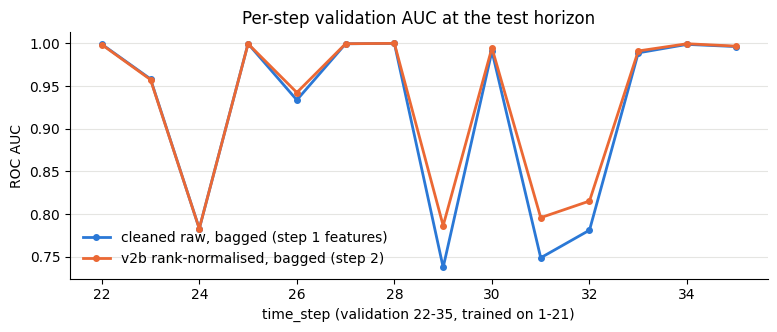

,auc_3fold,auc_hard,auc_horizon,gap_horizon,pr_auc
config,,,,,
v2b single LightGBM,0.9819,0.9563,0.9133,-0.0197,0.9178
v2b bagged x5,0.9822,0.9567,0.9135,-0.0193,0.9180
v2b random forest alone,0.9601,0.8936,0.8134,-0.0649,0.8977
v2b blend lgbm 0.8 + rf 0.2,0.9787,0.9465,0.8969,-0.0266,0.9137
v2b lgbm + isolation forest w=0.1,0.9785,0.9534,0.9074,-0.0195,0.8930
v2b lgbm + isolation forest w=0.2,0.9578,0.9331,0.8817,-0.0208,0.6973
"cleaned raw, bagged x5 (no normalisation)",0.9819,0.9555,0.8966,-0.0258,0.9155
v2 (incl. discrete) bagged x5,0.9815,0.9575,0.9173,-0.0176,0.9154


In [27]:
from scipy.stats import rankdata
from sklearn.ensemble import IsolationForest

norm_b = StepNormalizer(NORM_COLS, "rank", "replace"); COLS_B = norm_b.output_cols(RAW_CLEAN)
X_b, X_b_te = norm_b.transform(L[RAW], ts2)[COLS_B], norm_b.transform(test[RAW], test["time_step"])[COLS_B]
norm_2 = StepNormalizer(NORM_COLS_V2, "rank", "replace"); COLS_2 = norm_2.output_cols(RAW_CLEAN)
X_2, X_2_te = norm_2.transform(L[RAW], ts2)[COLS_2], norm_2.transform(test[RAW], test["time_step"])[COLS_2]

def iso_blend(w):
    def fp(Xtr, ytr, Xva, seed=0, sample_weight=None):
        p = lgbm300(Xtr, ytr, Xva, seed)
        a = -IsolationForest(n_estimators=300, random_state=seed, n_jobs=-1).fit(Xtr[ytr == 0]).score_samples(Xva)
        return (1 - w) * rankdata(p) / len(p) + w * rankdata(a) / len(a)
    return fp

stab_rows, stab_summ, stab_steps = [], [], {}
for name, fp, seeds in [("v2b single LightGBM", lgbm300, (0, 1, 2)),
                        ("v2b bagged x5", bagged_fit_predict(lgbm300), (0, 1, 2)),
                        ("v2b random forest alone", rf_fit_predict_w, (0, 1, 2)),
                        ("v2b blend lgbm 0.8 + rf 0.2", rank_blend_fit_predict({"l": lgbm300, "r": rf_fit_predict_w}, {"l": 0.8, "r": 0.2}), (0, 1, 2)),
                        ("v2b lgbm + isolation forest w=0.1", iso_blend(0.1), (0, 1)),
                        ("v2b lgbm + isolation forest w=0.2", iso_blend(0.2), (0, 1))]:
    r, s, d = run2(name, X_b, fp=fp, seeds=seeds); stab_rows.append(r); stab_summ.append(d); stab_steps[name] = s
r, s, d = run2("cleaned raw, bagged x5 (no normalisation)", L[RAW_CLEAN], fp=bagged_fit_predict(lgbm300)); stab_rows.append(r); stab_summ.append(d); stab_steps["raw bagged"] = s
r, s, d = run2("v2 (incl. discrete) bagged x5", X_2, fp=bagged_fit_predict(lgbm300)); stab_rows.append(r); stab_summ.append(d)
cv_stab = pd.DataFrame(stab_summ); pd.concat(stab_rows).to_csv("artifacts/cv_stability.csv", index=False); cv_stab.to_csv("artifacts/cv_stability_summary.csv", index=False)

# per-step AUC on the horizon fold: step-1 model vs the step-2 model
def horizon_curve(s):
    cols = [c for c in s.columns if c.startswith("22-35/")]
    return s[cols].mean(axis=1).loc[22:35]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(horizon_curve(stab_steps["raw bagged"]).index, horizon_curve(stab_steps["raw bagged"]).values, color=C1, lw=2, marker="o", ms=4, label="cleaned raw, bagged (step 1 features)")
ax.plot(horizon_curve(stab_steps["v2b bagged x5"]).index, horizon_curve(stab_steps["v2b bagged x5"]).values, color=C2, lw=2, marker="o", ms=4, label="v2b rank-normalised, bagged (step 2)")
ax.set(xlabel="time_step (validation 22-35, trained on 1-21)", ylabel="ROC AUC", title="Per-step validation AUC at the test horizon")
ax.legend(frameon=False, loc="lower left"); ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e5e5e2"); ax.set_axisbelow(True)
plt.show()
cv_stab.set_index("config").round(4)

Bagging is a small, consistent gain on every metric at no risk. The Random Forest is far weaker
at the horizon (its own AUC there is ~0.83) and drags any blend down; the Isolation Forest blend
hurts at every weight, so post-shutdown novelty is not "anomalous" in feature space in a way a
licit-only model can see. Decision: v2b features, LightGBM 300 rounds, five-seed bag.

## 15. Step-2 submissions

Three files, designed as controlled pairs against sub_03 (cleaned raw, single seed):

| file | model | prices |
|---|---|---|
| sub_06 | cleaned raw, bagged x5 | bagging alone (vs sub_03) |
| sub_04 | v2b rank-normalised, bagged x5 | normalisation (vs sub_06) — **primary** |
| sub_05 | v2 incl. discrete ranks, bagged x5 | discrete ranks (vs sub_04) |

In [28]:
ytr_all = y2.to_numpy().astype(int)
def fit_bag_predict(Xtr, Xte, seeds=(0, 1, 2, 3, 4)):
    return np.mean([lgb.LGBMClassifier(**{**LGBM_PARAMS, "n_estimators": FIXED_ROUNDS, "random_state": s}).fit(Xtr, ytr_all).predict_proba(Xte)[:, 1] for s in seeds], axis=0)

subs = [("sub_06_lgbm_clean_bagged5.csv", "cleaned raw, bagged x5 (no normalisation)", L[RAW_CLEAN], test[RAW_CLEAN]),
        ("sub_04_lgbm_v2b_ranknorm_bagged5.csv", "v2b bagged x5", X_b, X_b_te),
        ("sub_05_lgbm_v2_ranknorm_discrete_bagged5.csv", "v2 (incl. discrete) bagged x5", X_2, X_2_te)]
step2_lines = []
for fname, cfg, Xtr_f, Xte_f in subs:
    path = write_submission(fit_bag_predict(Xtr_f, Xte_f), fname)
    d = cv_stab[cv_stab.config == cfg].iloc[0]
    step2_lines.append(f"| {date.today()} | {fname} | {cfg} | {Xtr_f.shape[1]} | {FIXED_ROUNDS} x5 | {d.auc_3fold:.4f} | {d.auc_hard:.4f} | {d.auc_horizon:.4f} | {d.pr_auc:.4f} | _pending_ |")
    print("wrote", path)

header = ("\n## Step 2 (drift): rolling CV incl. the 14-step horizon fold\n\n"
          "| date | file | config | n features | rounds | CV AUC 3-fold | CV AUC hard fold 22-28 | CV AUC horizon 22-35 | CV PR-AUC | public LB |\n"
          "|---|---|---|---|---|---|---|---|---|---|\n")
txt = ledger.read_text()
if "## Step 2 (drift)" not in txt:
    txt += header
for ln in step2_lines:
    if ln.split("|")[2].strip() not in txt:
        txt += ln + "\n"
ledger.write_text(txt)
print("\n".join(step2_lines))
print("\nprimary upload: sub_04. Fill in the public LB column of results.md after uploading.")

wrote submissions/sub_06_lgbm_clean_bagged5.csv


wrote submissions/sub_04_lgbm_v2b_ranknorm_bagged5.csv


wrote submissions/sub_05_lgbm_v2_ranknorm_discrete_bagged5.csv
| 2026-09-26 | sub_06_lgbm_clean_bagged5.csv | cleaned raw, bagged x5 (no normalisation) | 159 | 300 x5 | 0.9819 | 0.9555 | 0.8966 | 0.9155 | _pending_ |
| 2026-09-26 | sub_04_lgbm_v2b_ranknorm_bagged5.csv | v2b bagged x5 | 159 | 300 x5 | 0.9822 | 0.9567 | 0.9135 | 0.9180 | _pending_ |
| 2026-09-26 | sub_05_lgbm_v2_ranknorm_discrete_bagged5.csv | v2 (incl. discrete) bagged x5 | 159 | 300 x5 | 0.9815 | 0.9575 | 0.9173 | 0.9154 | _pending_ |

primary upload: sub_04. Fill in the public LB column of results.md after uploading.
